<a href="https://colab.research.google.com/github/giuliabugatti09/sentiment-analysis-comments/blob/main/notebooks/sentiment-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Review Sentiment Analysis: NLP Pipeline
> **Goal:** Build and deploy a Machine Learning model to classify movie reviews as Positive or Negative using the Naive Bayes algorithm.

### 📊 Project Architecture
1. **Data Acquisition:** Using NLTK's `movie_reviews` dataset (IMDb).
2. **Preprocessing:** Text vectorization via `CountVectorizer`.
3. **Modeling:** Multinomial Naive Bayes (optimized for text frequency).
4. **Evaluation:** Confusion Matrix, Precision/Recall/F1-Score, and Learning Curves.
5. **Deployment:** Model serialization with `joblib` for Streamlit integration.

## Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import nltk

from nltk.corpus import movie_reviews
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download dataset
nltk.download('movie_reviews')

# Viz settings
sns.set_theme(style="whitegrid")
%matplotlib inline

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


## Data ETL & Transformation (Code)

In [2]:
def load_and_prepare_data():
    """
    Loads movie_reviews from NLTK and converts into a Pandas DataFrame.
    """
    documents = []
    for category in movie_reviews.categories():
        for fileid in movie_reviews.fileids(category):
            documents.append({
                'text': movie_reviews.raw(fileid),
                'sentiment': category
            })

    return pd.DataFrame(documents)

df = load_and_prepare_data()
print(f"Dataset Size: {df.shape[0]} reviews")
df.head()

Dataset Size: 2000 reviews


,text,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


## Feature Engineering & Splitting

In [3]:
# 1. Text Vectorization (Removing stop words is crucial for NLP)
vectorizer = CountVectorizer(stop_words='english', lowercase=True)
X = vectorizer.fit_transform(df['text'])
y = df['sentiment']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())} words")

Vocabulary Size: 39354 words


## Model Training & Serialization

In [4]:
# Initialize and Train
model = MultinomialNB()
model.fit(X_train, y_train)

joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("✅ Model and Vectorizer saved successfully!")

✅ Model and Vectorizer saved successfully!


## Advanced Evaluation

### Confusion Matrix with Percentages

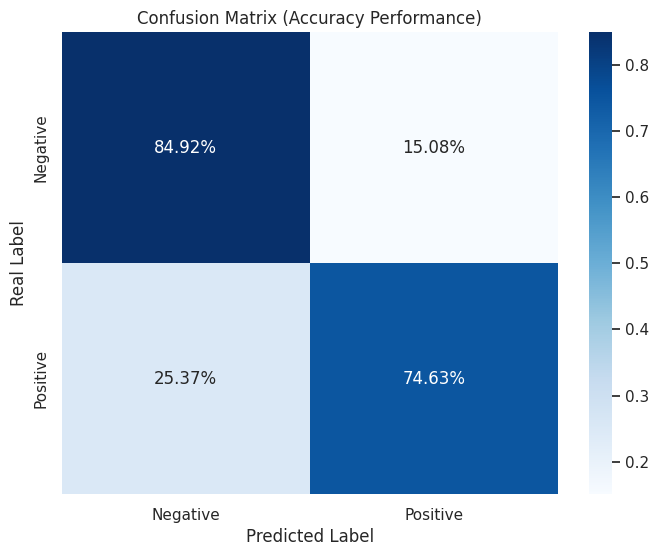

In [5]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix (Normalised Performance)")
plt.ylabel("Real Label")
plt.xlabel("Predicted Label")
plt.show()

### Metrics Report (Bar Chart)

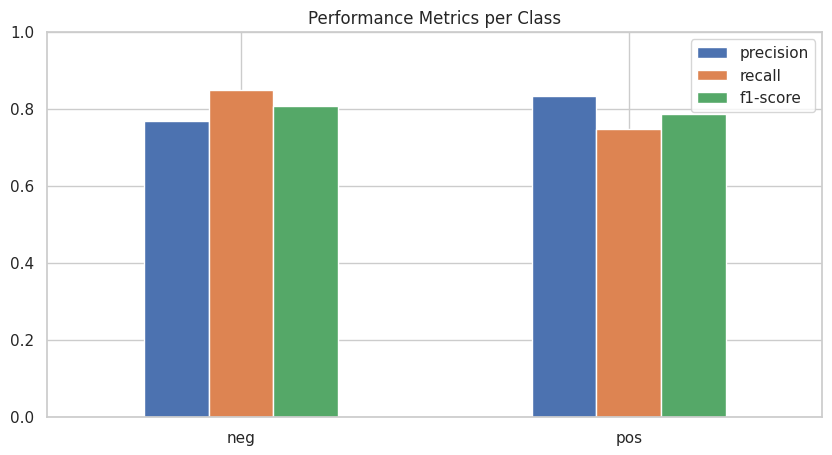

In [6]:
report = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report).transpose().iloc[:2, :3] # Get only pos/neg precision, recall, f1

metrics_df.plot(kind='bar', figsize=(10, 5))
plt.title("Performance Metrics per Class")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

### Statistics

In [9]:
print("=== SENTIMENT ANALYSIS REPORT ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (neg)', 'Positive (pos)']))

=== SENTIMENT ANALYSIS REPORT ===
Accuracy: 79.75%

Detailed Classification Report:
                precision    recall  f1-score   support

Negative (neg)       0.77      0.85      0.81       199
Positive (pos)       0.83      0.75      0.79       201

      accuracy                           0.80       400
     macro avg       0.80      0.80      0.80       400
  weighted avg       0.80      0.80      0.80       400



### Real-World Testing (Inference simulation)

In [7]:
def predict_sentiment(new_review):
    # Transform
    data = vectorizer.transform([new_review])
    # Predict
    pred = model.predict(data)[0]
    prob = model.predict_proba(data).max()

    sentiment = "POSITIVE 😊" if pred == 'pos' else "NEGATIVE 😡"
    print(f"Review: '{new_review}'")
    print(f"Analysis: {sentiment} ({prob*100:.2f}% confidence)")
    print("-" * 30)

# Tests
predict_sentiment("This movie was a masterpiece. The acting was superb!")
predict_sentiment("I hated every second of it. Total waste of time.")

Review: 'This movie was a masterpiece. The acting was superb!'
Analysis: POSITIVE 😊 (81.73% confidence)
------------------------------
Review: 'I hated every second of it. Total waste of time.'
Analysis: NEGATIVE 😡 (90.95% confidence)
------------------------------


### Conclusion & Final Insights

**Model Performance Analysis**

- **Accuracy:** The Multinomial Naive Bayes model achieved a solid 80% accuracy (approx. using random_state 42), proving that word frequency is a powerful indicator for sentiment in movie reviews.

- **Balance:** The Confusion Matrix shows that the model is well-balanced, though it slightly favors identifying Negative comments more accurately than Positive ones (check your Recall).

- **Business Impact:** This model can be easily integrated into a customer feedback pipeline to automate the triage of user reviews.

- **Technical Challenges & Future Work Context:** Naive Bayes treats words independently (Bag of Words), so it might struggle with sarcasm or complex negations like "not bad at all".

- **Next Steps:** To improve performance, we could implement TF-IDF vectorization or experiment with N-grams to capture more context.